
File: tumor.root
Entries: 100000
Accepted detector gammas: 2147

File: phantom.root
Entries: 100000
Accepted detector gammas: 4291
Tumor angle count: 2147
Phantom angle count: 4291


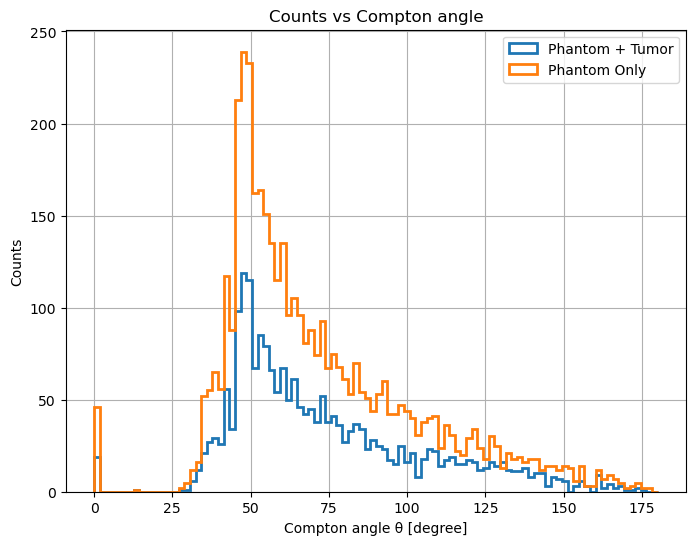

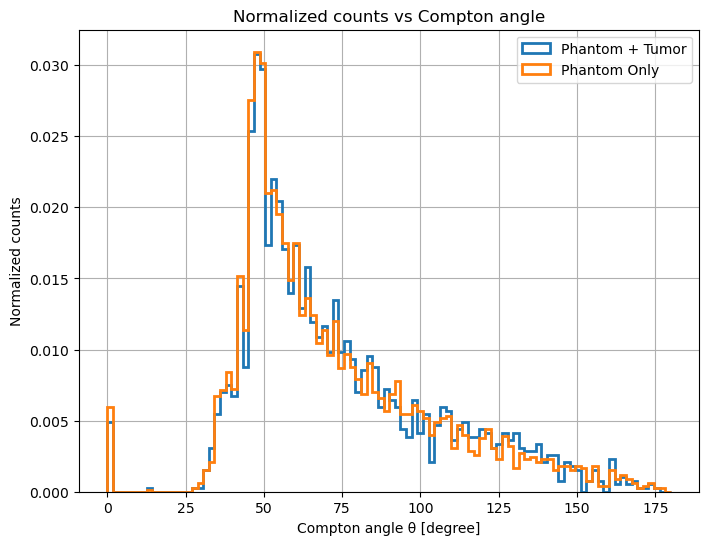

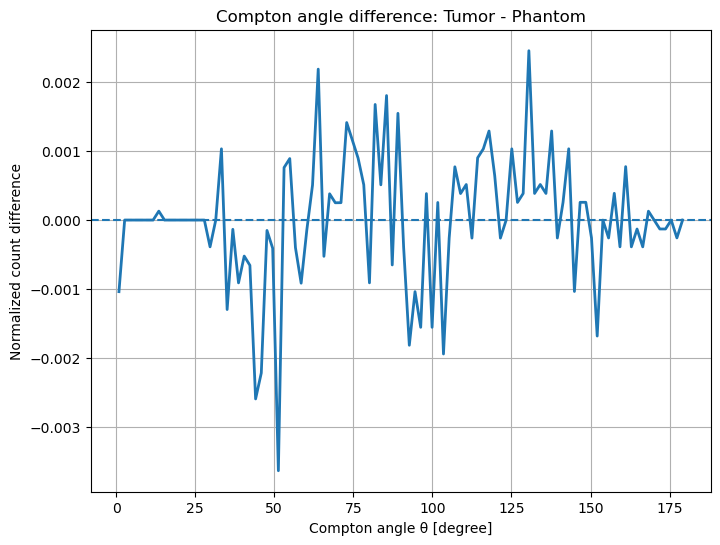

In [6]:
import ROOT
import math
import numpy as np
import matplotlib.pyplot as plt

# =========================
# USER SETTINGS
# =========================
tumor_file = "tumor.root"
phantom_file = "phantom.root"
tree_name = "t"

detector_vlms = [4, 5, 6]

E0 = 662.0   # incident gamma energy [keV]
me = 511.0   # electron rest mass energy [keV]

# =========================
# FUNCTION: GET COMPTON ANGLES
# =========================
def get_compton_angles(root_file):

    f = ROOT.TFile.Open(root_file)
    if not f or f.IsZombie():
        raise RuntimeError(f"Could not open ROOT file: {root_file}")

    t = f.Get(tree_name)
    if not t:
        raise RuntimeError(f"Could not find tree {tree_name} in {root_file}")

    angles = []

    print("\nFile:", root_file)
    print("Entries:", t.GetEntries())

    for entry in t:

        n = min(
            len(entry.pdg),
            len(entry.vlm),
            len(entry.et)
        )

        for i in range(n):

            # select only gammas
            if int(entry.pdg[i]) != 22:
                continue

            # select only detector volumes
            if int(entry.vlm[i]) not in detector_vlms:
                continue

            Es = float(entry.et[i])   # scattered gamma energy

            if Es <= 0 or Es >= E0:
                continue

            # Compton formula
            cos_theta = 1.0 - me * (1.0 / Es - 1.0 / E0)

            if cos_theta < -1.0 or cos_theta > 1.0:
                continue

            theta = math.acos(cos_theta)   # radians
            angles.append(theta)

    f.Close()

    angles = np.array(angles)

    print("Accepted detector gammas:", len(angles))

    return angles


# =========================
# GET ANGLES
# =========================
angles_tumor = get_compton_angles(tumor_file)
angles_phantom = get_compton_angles(phantom_file)

# Convert radians to degrees
angles_tumor_deg = np.degrees(angles_tumor)
angles_phantom_deg = np.degrees(angles_phantom)

print("Tumor angle count:", len(angles_tumor_deg))
print("Phantom angle count:", len(angles_phantom_deg))


# =========================
# PLOT: COUNTS vs COMPTON ANGLE
# =========================
plt.figure(figsize=(8, 6))

plt.hist(
    angles_tumor_deg,
    bins=100,
    range=(0, 180),
    histtype="step",
    linewidth=2,
    density=False,
    label="Phantom + Tumor"
)

plt.hist(
    angles_phantom_deg,
    bins=100,
    range=(0, 180),
    histtype="step",
    linewidth=2,
    density=False,
    label="Phantom Only"
)

plt.xlabel("Compton angle θ [degree]")
plt.ylabel("Counts")
plt.title("Counts vs Compton angle")
plt.legend()
plt.grid(True)
plt.show()


# =========================
# OPTIONAL: NORMALIZED COMPARISON
# =========================
plt.figure(figsize=(8, 6))

plt.hist(
    angles_tumor_deg,
    bins=100,
    range=(0, 180),
    histtype="step",
    linewidth=2,
    density=True,
    label="Phantom + Tumor"
)

plt.hist(
    angles_phantom_deg,
    bins=100,
    range=(0, 180),
    histtype="step",
    linewidth=2,
    density=True,
    label="Phantom Only"
)

plt.xlabel("Compton angle θ [degree]")
plt.ylabel("Normalized counts")
plt.title("Normalized counts vs Compton angle")
plt.legend()
plt.grid(True)
plt.show()


# =========================
# OPTIONAL: DIFFERENCE PLOT
# Tumor - Phantom
# =========================
bins = np.linspace(0, 180, 101)

h_tumor, edges = np.histogram(
    angles_tumor_deg,
    bins=bins,
    density=True
)

h_phantom, _ = np.histogram(
    angles_phantom_deg,
    bins=bins,
    density=True
)

centers = 0.5 * (edges[:-1] + edges[1:])
diff = h_tumor - h_phantom

plt.figure(figsize=(8, 6))
plt.plot(centers, diff, linewidth=2)
plt.axhline(0, linestyle="--")

plt.xlabel("Compton angle θ [degree]")
plt.ylabel("Normalized count difference")
plt.title("Compton angle difference: Tumor - Phantom")
plt.grid(True)
plt.show()